In [3]:
!pip install wikipedia

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11758 sha256=802bff4ddcf8f35ca57374471fca4fe169e564c63c9eb0d2766f7524463979b4
  Stored in directory: /home/yashvir/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


## Retriever in LangChain

- Fetches relevant documents based on a user query.  
- Works with different data sources (vector stores, databases, etc.).  
- Multiple types available (vector, multi-query, compression, etc.).  
- All retrievers are **Runnables** and support invoke, batch, and stream.
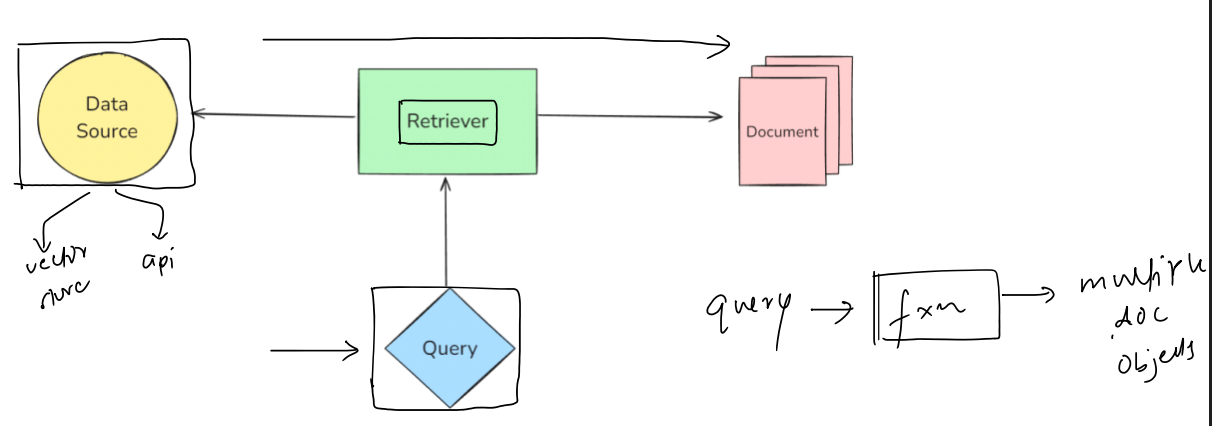
## Types of Retrievers (Based on Data Source)

- **WikipediaRetriever** – Queries the Wikipedia API to fetch relevant content for a given user query.  

- **VectorStoreRetriever** – Retrieves documents from a vector database using semantic similarity search.  

- **ArxivRetriever** – Fetches research papers and summaries from the arXiv database based on a query.


In [4]:
from langchain_community.retrievers import WikipediaRetriever
retriever = WikipediaRetriever(top_k_results=2,lang="en")
docs = retriever.invoke("MS Dhoni")
print(type(docs))

<class 'list'>


In [7]:
for i,doc in enumerate(docs):
    print(f"Document {i}:")
    print(doc.page_content[:100])

Document 0:
Mahendra Singh  Dhoni ([məˈɦeːnd̪ɾə ˈsɪŋɡʱ ˈd̪ʱoːniː] ; born 7 July 1981) is an Indian professional 
Document 1:
M.S. Dhoni: The Untold Story is a 2016 Indian Hindi-language biographical sports drama film directed


# Vector Store Retriever in LangChain

A **Vector Store Retriever** is the most common retriever in LangChain that searches and fetches documents from a vector store using semantic similarity (vector embeddings).

### How It Works

1. Store documents in a vector store (e.g., FAISS, Chroma, Weaviate).  
2. Convert each document into a dense vector using an embedding model.  
3. When a user enters a query:  
   - The query is converted into a vector.  
   - The retriever compares the query vector with stored vectors.  
   - It returns the top-k most similar documents.  

---

In [8]:
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
load_dotenv()

/mnt/d/Learning/Java/genAI/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [18]:
embeddings = OpenAIEmbeddings()

# Load existing Chroma DB (persist_directory must match your saved DB)
vectorstore = Chroma(
    persist_directory="chroma_db",
    embedding_function=embeddings,
    collection_name="sample"
)
# Option 1: Get all stored documents
all_docs = vectorstore.get(include=["documents", "metadatas"])

print(all_docs["documents"])

['Cricket is a popular sport played worldwide.', 'Artificial Intelligence enables machines to learn from data.', 'Python is a widely used programming language for data science.', 'Mumbai Indians captain Rohit Sharma is known for his elegant batting and leadership in the IPL.', 'Jasprit Bumrah is a key fast bowler for Mumbai Indians, famous for his deadly yorkers.', 'Suryakumar Yadav plays aggressive and innovative shots for Mumbai Indians in the middle order.', 'Hardik Pandya is an all-rounder for Mumbai Indians, contributing with both bat and ball.', 'Ishan Kishan is a wicketkeeper-batsman for Mumbai Indians known for explosive starts.', 'MS Dhoni is one of the most successful captains in IPL history, known for his sharp cricketing mind, exceptional wicketkeeping skills, and ability to finish matches under pressure for Chennai Super Kings.', 'Ravindra Jadeja is a star all-rounder for Chennai Super Kings, contributing with bat, ball, and fielding.', 'Ruturaj Gaikwad is a top-order bats

In [21]:
# Option 2: Use as retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})
query = "MS Dhoni"

In [24]:
results = retriever.invoke(query)
for doc in results:
    print(doc.page_content)

MS Dhoni is one of the most successful captains in IPL history, known for his sharp cricketing mind, exceptional wicketkeeping skills, and ability to finish matches under pressure for Chennai Super Kings.
MS Dhoni, captain of Chennai Super Kings, is admired for his calm leadership and finishing abilities.


In [25]:
results = vectorstore.similarity_search(query, k=2)
for doc in results:
    print(doc.page_content)

MS Dhoni is one of the most successful captains in IPL history, known for his sharp cricketing mind, exceptional wicketkeeping skills, and ability to finish matches under pressure for Chennai Super Kings.
MS Dhoni, captain of Chennai Super Kings, is admired for his calm leadership and finishing abilities.


## Why Use Retriever Instead of Direct Vector Store?

- **Abstraction Layer** – Provides a standard interface, making it easy to switch vector store backends.  
- **Chain Integration** – Retrievers are runnables and integrate smoothly with RAG and LangChain workflows.  
- **Flexible Retrieval Logic** – Supports top-k, filtering, MMR, and other advanced search strategies.

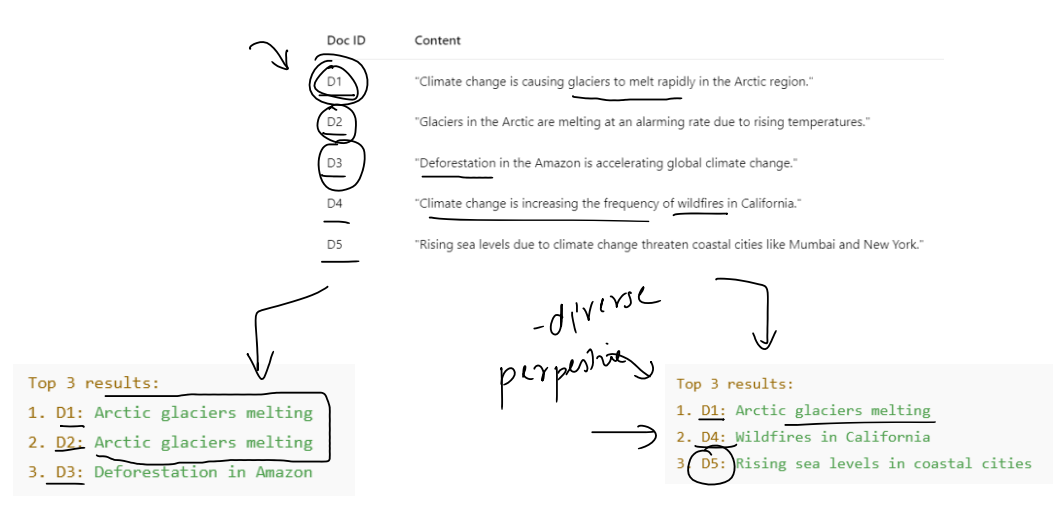
## Based on Retrieval Strategy – MMR Retriever

**MMR (Max Marginal Relevance)** is a retrieval algorithm that reduces redundancy in search results while maintaining high relevance to the query.

### Why Use MMR Retriever?

In regular similarity search, retrieved documents may:
- Be very similar to each other  
- Repeat the same information  
- Lack diverse perspectives  

### How MMR Works

- Selects the most relevant document first  
- Then selects the next document that is both relevant and least similar to already selected documents  

### Why It’s Useful in RAG

- Ensures the context window contains diverse yet relevant information  
- Especially helpful when documents are semantically overlapping  


In [26]:
# MMR 
# Sample documents
docs = [
    Document(page_content="LangChain makes it easy to work with LLMs."),
    Document(page_content="LangChain is used to build LLM based applications."),
    Document(page_content="Chroma is used to store and search document embeddings."),
    Document(page_content="Embeddings are vector representations of text."),
    Document(page_content="MMR helps you get diverse results when doing similarity search."),
    Document(page_content="LangChain supports Chroma, FAISS, Pinecone, and more."),
]
vector_store = Chroma(
    embedding_function=OpenAIEmbeddings(),
    persist_directory='chroma_db',
    collection_name='mmr'
)

In [27]:
# Add documents (only needed first time)
vector_store.add_documents(docs)
vector_store.persist()

/tmp/ipykernel_3144/4210157592.py:3: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vector_store.persist()


In [35]:
retriever = vector_store.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k":3,
        "lambda_mult": 0.5     # Relevance-diversity balance
    }
)

In [36]:
results = retriever.invoke("What is LangChain?")

for i, doc in enumerate(results, 1):
    print(f"\nResult {i}: {doc.page_content}")


Result 1: LangChain is used to build LLM based applications.

Result 2: LangChain supports Chroma, FAISS, Pinecone, and more.

Result 3: Embeddings are vector representations of text.


## MultiQuery Retriever

Sometimes a single query does not capture all the ways information is phrased in documents.

### Problem

Query:  
**"How can I stay healthy?"**

It could mean:
- What should I eat?  
- How often should I exercise?  
- How can I manage stress?  

A simple similarity search might miss documents that don’t use the exact word **“healthy”**.

---

## How MultiQuery Retriever Works

1. Takes the original user query.  
2. Uses an LLM to generate multiple semantically different variations of the query.  
3. Performs retrieval for each generated sub-query.  
4. Combines and removes duplicate results.  

---

### Example

Original Query:  
**"How can I stay healthy?"**

Generated Queries:
1. What are the best foods to maintain good health?  
2. How often should I exercise to stay fit?  
3. What lifestyle habits improve mental and physical wellness?  
4. How can I boost my immune system naturally?  
5. What daily routines support long-term health? 
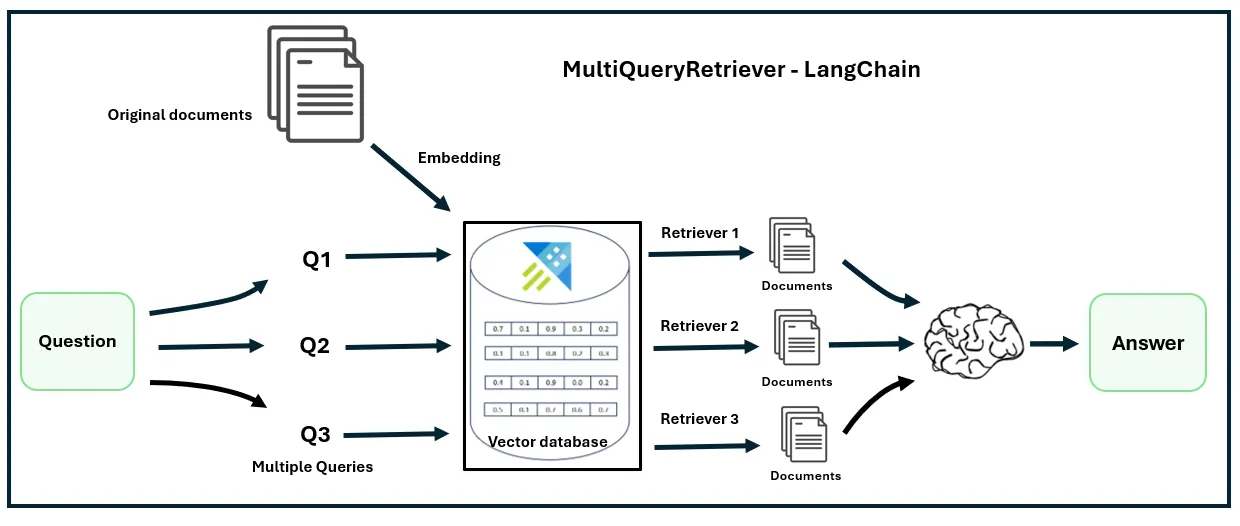


# 🗜️ Contextual Compression Retriever (LangChain)

The **Contextual Compression Retriever** improves retrieval quality by:

- Retrieving documents
- Compressing them based on the user query
- Returning only the relevant content
- Removing unnecessary noise

---

## ❌ Problem with Normal Retrieval

**Query:**
> "What is photosynthesis?"

### 📄 Retrieved Document (By traditional Retriver):

> "The Grand Canyon is a famous natural site.  
> Photosynthesis is how plants convert light into energy.  
> Many tourists visit every year."

---

## 🚨 Problem

- The retriever returns the **entire paragraph**
- Only **one sentence** is relevant to the query
- The rest is **irrelevant noise** which waste LLM context window and confuse model
---

## ✅ What Contextual Compression Does

Returns revelant part -> "Photosynthesis is the process by which plants convert sunlight into energy."

### Benefits:
- Removes irrelevant sentences
- Reduces token usage
- Saves LLM context window
---

# ⚙️ How It Works

1. **Base Retriever** (FAISS, Chroma, etc.) retrieves N documents.
2. A **Compressor** (usually an LLM) is applied to each document.
3. The compressor keeps only content relevant to the query.
4. Irrelevant text is discarded.

---
# ⚙️ When to use?
- Long and contain mixed information document
- Reduce Context length of LLMs
- Improve answer accuracy in RAG pipeline
